In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import beta, norm

In [2]:
# 1. Simulate a skewed population of model accuracies
np.random.seed(42)
population_size = 10000
population = beta.rvs(a=2, b=5, size=population_size) * 100  # Accuracy in %

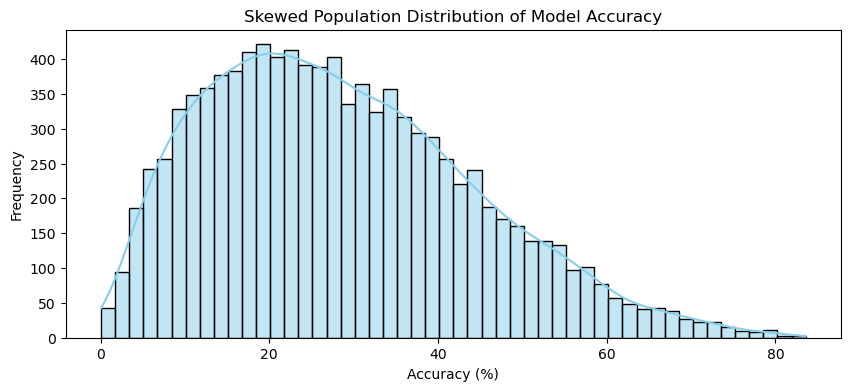

In [3]:
# 2. Visualize the population distribution
plt.figure(figsize=(10, 4))
sns.histplot(population, bins=50, kde=True, color='skyblue')
plt.title("Skewed Population Distribution of Model Accuracy")
plt.xlabel("Accuracy (%)")
plt.ylabel("Frequency")
plt.show()

In [4]:
# 3. Central Limit Theorem: Sampling distribution of sample means
sample_size = 30
num_samples = 1000
sample_means = []

for _ in range(num_samples):
    sample = np.random.choice(population, size=sample_size, replace=False)
    sample_means.append(np.mean(sample))

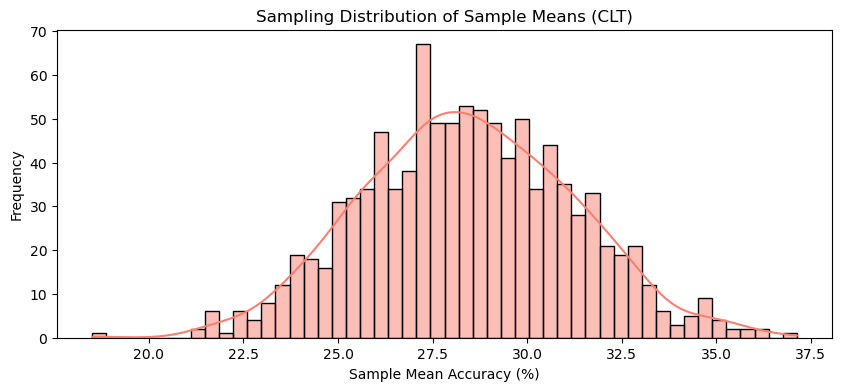

In [5]:
# 4. Visualize the sampling distribution
plt.figure(figsize=(10, 4))
sns.histplot(sample_means, bins=50, kde=True, color='salmon')
plt.title("Sampling Distribution of Sample Means (CLT)")
plt.xlabel("Sample Mean Accuracy (%)")
plt.ylabel("Frequency")
plt.show()

In [6]:
# 5. Standard Error and Confidence Interval from one sample
one_sample = np.random.choice(population, size=sample_size, replace=False)
sample_mean = np.mean(one_sample)
sample_std = np.std(one_sample, ddof=1)
standard_error = sample_std / np.sqrt(sample_size)

In [7]:
# 95% Confidence Interval
z_score = norm.ppf(0.975)  # For 95% CI
ci_lower = sample_mean - z_score * standard_error
ci_upper = sample_mean + z_score * standard_error

In [8]:
# 6. Display results
print(f"Sample Mean Accuracy: {sample_mean:.2f}%")
print(f"Standard Error: {standard_error:.2f}")
print(f"95% Confidence Interval: [{ci_lower:.2f}%, {ci_upper:.2f}%]")

Sample Mean Accuracy: 30.61%
Standard Error: 3.16
95% Confidence Interval: [24.41%, 36.81%]


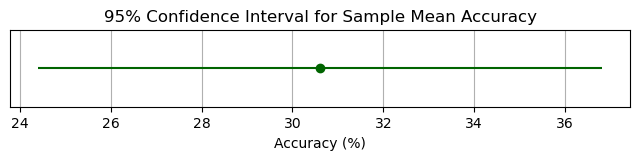

In [9]:
# 7. Visualize CI
plt.figure(figsize=(8, 1))
plt.errorbar(x=sample_mean, y=0, xerr=z_score * standard_error, fmt='o', color='darkgreen')
plt.title("95% Confidence Interval for Sample Mean Accuracy")
plt.xlabel("Accuracy (%)")
plt.yticks([])
plt.grid(True)
plt.show()